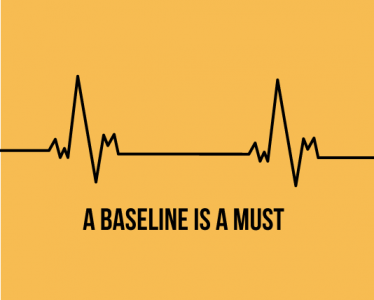

## 🤏 Baseline with logistic regression

### 🎒 Packages

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', None)
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.svm import LinearSVC
import wandb
import numpy as np
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


### 🚙 Utilities

In [2]:
train_path = Path("..") / "data" / "train" / "train.tsv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test" / "train.tsv"

### 📊 Data

In [3]:
labels =["Ne", "S.Ne", "N", "S.Po", "Po"]

In [4]:
baseline_df = pd.read_csv(train_path, sep="\t")
baseline_df.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1
1,2,1,A series of escapades demonstrating the adage that what is good for the goose,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [5]:
baseline_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   PhraseId    156060 non-null  int64
 1   SentenceId  156060 non-null  int64
 2   Phrase      156060 non-null  str  
 3   Sentiment   156060 non-null  int64
dtypes: int64(3), str(1)
memory usage: 4.8 MB


### ➿ Loops

In [6]:
clean_df = baseline_df.copy()

#### 👶 Basic data clearning

In [7]:
STOP_WORDS = set(stopwords.words("english"))

keep_words = {
    "no", "not", "never", "nor", "n't",
    "very", "too", "so", "only", "just",
    "but", "against", "up", "down",
    "more", "most", "less", "least"
}

# optional domain-specific words to REMOVE
contextual_words = {"movie", "film"}

# final stopwords
STOP_WORDS = STOP_WORDS.union(contextual_words) - keep_words


def cleaning(text):
    # lowercase
    text = text.lower()
    
    # remove parser's artifact
    text = re.sub(r"-lrb-|-rrb-", " ", text)
    
    # contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    
    # punctuation
    text = re.sub(r"[^a-z!? ]", " ", text)
    
    # split by <space>
    tokens = text.split()
    
    # stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS]
    
    # join
    text = " ".join(tokens)
    
    return text

In [8]:
clean_df["Phrase"] = clean_df["Phrase"].apply(func=lambda text : cleaning(text))

In [9]:
clean_df = clean_df[clean_df["Phrase"] != ""]

In [10]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 154687 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   PhraseId    154687 non-null  int64
 1   SentenceId  154687 non-null  int64
 2   Phrase      154687 non-null  str  
 3   Sentiment   154687 non-null  int64
dtypes: int64(3), str(1)
memory usage: 5.9 MB


In [11]:
features = "Phrase"

target = "Sentiment"

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    clean_df[features], 
    clean_df[target], 
    test_size=0.1, 
    random_state=42, 
    stratify=clean_df[target],
)

#### 🛫 Feature engineerings with TFIDFVectorizer

##### ⏬ Embedded in the training step for store the metadata

#### ⚾ Try baseline: Logistic Regression

##### 👨‍⚖️ Training step

In [13]:
print(type(X_train))

<class 'pandas.Series'>


In [ ]:
#################################################################### - Set up configuration for this train
vectorizer_config = {
    "type": "TF-IDF",
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
}

config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LogisticRegression",
    "vectorizer": vectorizer_config,
    "C": 1.0,
    "max_iter": 500,
    "dataset": "Rotten Tomatoes",
    "class_weight" : None
}

#################################################################### - Init wandb
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="ML_LogReg",
    name="logreg_tfidf_v1",
    config=config
)
#################################################################### - Traning step [Preprocessing - feature engineering]
vectorizer = TfidfVectorizer(
    lowercase=vectorizer_config["lowercase"],
    stop_words=vectorizer_config["stop_words"],
    ngram_range=vectorizer_config["ngram_range"],
    min_df=vectorizer_config["min_df"],
    max_df=vectorizer_config["max_df"],
)

X_train_vec = vectorizer.fit_transform(X_train)

lr = LogisticRegression(
        max_iter=config["max_iter"], 
        class_weight=config["class_weight"]
    )

lr.fit(X_train_vec, y_train)
#################################################################### - Evaluate on val
X_val_vec = vectorizer.transform(X_val)
y_pred = lr.predict(X_val_vec)

acc = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average="macro")
f1_weighted = f1_score(y_val, y_pred, average="weighted")
#################################################################### - Log the metrics

wandb.log({
    "val_accuracy": acc,
    "val_f1_macro": f1_macro,
    "val_f1_weighted": f1_weighted,
    "confusion_matrix" : wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_val.to_numpy(),
        preds=y_pred,
        class_names=labels
    )
})
#################################################################### - End

#### 👦 Evaluate and decision

In [15]:
print(classification_report(y_val, y_pred))

print("*****************************************************")

# y_pred = lr.predict(X_val_vec)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Macro-F1: ", f1_score(y_val, y_pred, average="macro"))
print("Weighted-F1: ", f1_score(y_val, y_pred, average="weighted"))

              precision    recall  f1-score   support

           0       0.58      0.19      0.28       707
           1       0.57      0.39      0.46      2725
           2       0.68      0.88      0.77      7830
           3       0.60      0.51      0.55      3286
           4       0.65      0.28      0.39       921

    accuracy                           0.65     15469
   macro avg       0.61      0.45      0.49     15469
weighted avg       0.63      0.65      0.62     15469

*****************************************************
Accuracy: 0.6471652983386127
Macro-F1:  0.49022410095503066
Weighted-F1:  0.6218121174312604


In [16]:
def draw_cm(y_true, y_pred, labels=labels):
    cm = confusion_matrix(y_true=y_true, y_pred=y_pred)

    cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    # plt.figure(figsize=(10, 5))
    fig, axes = plt.subplots(figsize=(10, 5))

    cm.plot(
            cmap="Greens",
            ax=axes,
        )
    
    axes.set_xlabel("Predicted")
    axes.set_ylabel("Actual")

    plt.title("Confusion matrix")
    plt.show()
    

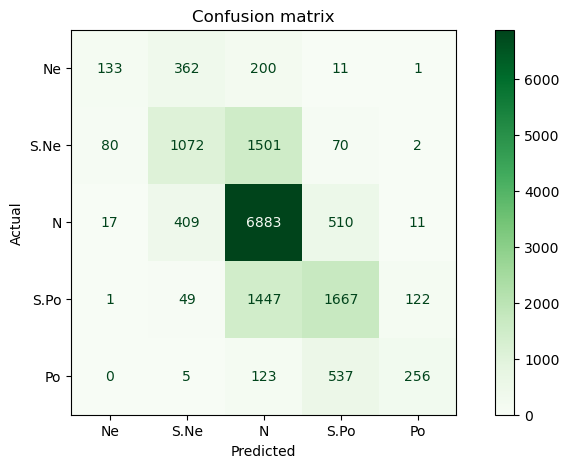

In [17]:
draw_cm(y_val, y_pred)

#### ❌ Error analysis

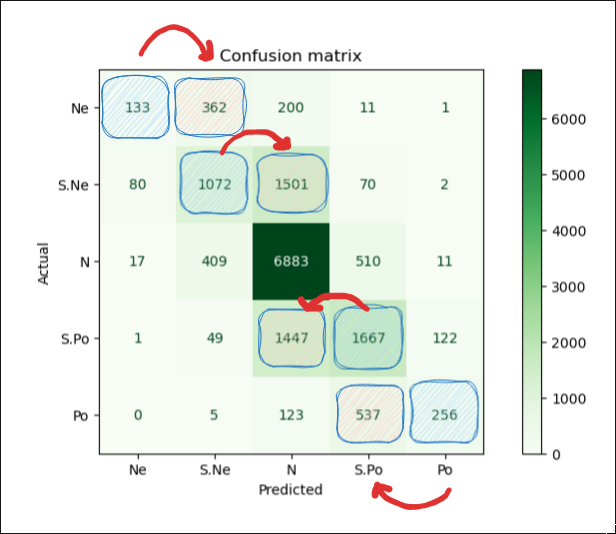

In [18]:
# Reset index to align everything
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

# Create DataFrame
error_df = pd.DataFrame({
    "text": X_val,
    "true": y_val,
    "pred": y_pred
})

# Add correctness flag
error_df["correct"] = error_df["true"] == error_df["pred"]

In [19]:
error_df.head()

,text,true,pred,correct
0,exists try eke emotional tug heart one fails get,0,2,False
1,neither promise nor threat so much wishful thinking,2,2,True
2,tony gayton script not give us anything not seen,1,2,False
3,blended satire,2,2,True
4,stumblebum,0,2,False


##### 🎥 Actual is positive -> Somewhat Positive

In [20]:
pos_to_somewhat = error_df[
    (error_df["true"] == 4) & (error_df["pred"] == 3)
]

print(pos_to_somewhat.sample(5)["text"])

14207                                                                         ming liang witty wistful new
7747     shines bright frozen tundra soap opera breathes extraordinary life private existence inuit people
7479                                                                                          absolute joy
1022                                                                                  one summer satisfies
9744                                                            laissez passer earmarks french cinema best
Name: text, dtype: str


##### 🎥 Actual is negative -> Somewhat Negative

In [21]:
neg_to_somewhat = error_df[
    (error_df["true"] == 0) & (error_df["pred"] == 1)
]

print(neg_to_somewhat.sample(5)["text"])

13832                                      left sour taste mouth
224      lack clarity audacity subject monstrous pathetic dahmer
3090                                        glazed tawdry b scum
11242        especially half past dead like rock wal mart budget
4780                    bored watching morvern callar characters
Name: text, dtype: str


##### 🎥 Actual is Ne, S.Ne, S.Po, Po -> Neural

In [22]:
to_neutral = error_df[
    (error_df["pred"] == 2) & (error_df["true"] != 2)
]

print(to_neutral.sample(5))

                                                                         text  \
13251                                                          so uninspiring   
7796                                                                   ragbag   
11461                                                        would characters   
7369   could not find stardom mapquest emailed point point driving directions   
6244                                                 intense scrutiny minutes   

       true  pred  correct  
13251     0     2    False  
7796      1     2    False  
11461     1     2    False  
7369      0     2    False  
6244      1     2    False  


#### 🛢️ Handle problems of data imbalance 

In [ ]:
#################################################################### - Set up configuration for this train
vectorizer_config = {
    "type": "TF-IDF",
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
}

config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LogisticRegression",
    "vectorizer": vectorizer_config,
    "C": 1.0,
    "max_iter": 500,
    "dataset": "Rotten Tomatoes",
    "class_weight" : "balanced"
}

#################################################################### - Init wandb
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="ML_LogReg",
    name="logreg_tfidf_v2",
    config=config
)
#################################################################### - Traning step [Preprocessing - feature engineering]
vectorizer = TfidfVectorizer(
    lowercase=vectorizer_config["lowercase"],
    stop_words=vectorizer_config["stop_words"],
    ngram_range=vectorizer_config["ngram_range"],
    min_df=vectorizer_config["min_df"],
    max_df=vectorizer_config["max_df"],
)

X_train_vec = vectorizer.fit_transform(X_train)

lr = LogisticRegression(
        max_iter=config["max_iter"], 
        class_weight=config["class_weight"]
    )

lr.fit(X_train_vec, y_train)
#################################################################### - Evaluate on val
X_val_vec = vectorizer.transform(X_val)
y_pred = lr.predict(X_val_vec)

acc = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average="macro")
f1_weighted = f1_score(y_val, y_pred, average="weighted")
#################################################################### - Log the metrics

wandb.log({
    "val_accuracy": acc,
    "val_f1_macro": f1_macro,
    "val_f1_weighted": f1_weighted,
    "confusion_matrix" : wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_val.to_numpy(),
        preds=y_pred,
        class_names=labels
    )
})
#################################################################### - End

In [27]:
print(classification_report(y_val, y_pred))

print("*****************************************************")

# y_pred = lr.predict(X_val_vec)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Macro-F1: ", f1_score(y_val, y_pred, average="macro"))
print("Weighted-F1: ", f1_score(y_val, y_pred, average="weighted"))

              precision    recall  f1-score   support

           0       0.33      0.63      0.44       707
           1       0.48      0.51      0.49      2725
           2       0.79      0.66      0.72      7830
           3       0.53      0.50      0.52      3286
           4       0.38      0.67      0.49       921

    accuracy                           0.60     15469
   macro avg       0.50      0.59      0.53     15469
weighted avg       0.64      0.60      0.61     15469

*****************************************************
Accuracy: 0.5983580063352512
Macro-F1:  0.5301964017711063
Weighted-F1:  0.6092848058381082


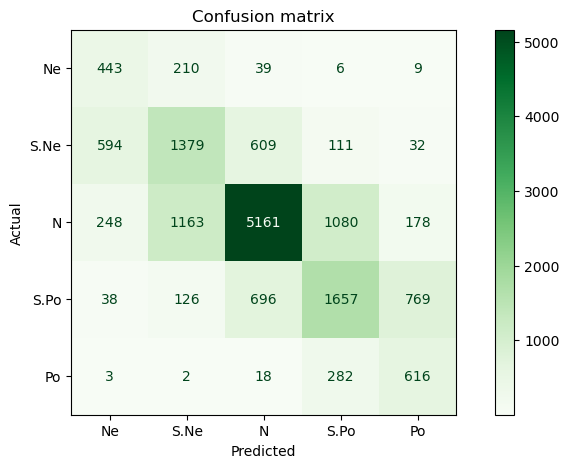

In [28]:
draw_cm(y_val, y_pred)

---

### 💀 Deperecated

#### 🗡️ Fix the class imbalance with class_weight

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

NameError: name 'X' is not defined

In [ ]:
def lower (text : str):
    return text.lower()

In [ ]:

def handle_negation(text : str):
    return re.sub(r"not\s+(\w+)", r"not_\1", text)

In [ ]:
def preprocessing(text : str):
    text = lower(text)
    text = handle_negation(text)
    return text

In [ ]:
X_train = X_train.apply(lambda text : preprocessing(text=text))
X_val = X_val.apply(lambda text : preprocessing(text=text))

In [ ]:
#################################################################### - Set up configuration for this train
vectorizer_config = {
    "type": "TF-IDF",
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2
}

config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LogisticRegression",
    "vectorizer": vectorizer_config,
    "C": 1.0,
    "max_iter": 500,
    "dataset": "Rotten Tomatoes",
    "class_weight" : "balanced"
}
#################################################################### - Init wandb
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="ML_LogReg",
    name="logreg_tfidf_v2",
    config=config
)
#################################################################### - Traning step [Preprocessing - feature engineering]
vectorizer = TfidfVectorizer(
    lowercase=vectorizer_config["lowercase"],
    stop_words=vectorizer_config["stop_words"],
    ngram_range=vectorizer_config["ngram_range"],
    min_df=vectorizer_config["min_df"]
)

X_train_vec = vectorizer.fit_transform(X_train)

lr = LogisticRegression(max_iter=config["max_iter"], class_weight=config["class_weight"])
lr.fit(X_train_vec, y_train)
#################################################################### - Evaluate on val
X_val_vec = vectorizer.transform(X_val)
y_pred = lr.predict(X_val_vec)

acc = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average="macro")
f1_weighted = f1_score(y_val, y_pred, average="weighted")
cm = confusion_matrix(y_true=y_val, y_pred=y_pred)
#################################################################### - Log the metrics

wandb.log({
    "val_accuracy": acc,
    "val_f1_macro": f1_macro,
    "val_f1_weighted": f1_weighted,
    "confusion_matrix" : cm
})
####################################################################

#### 👦 Evaluate and decision

In [ ]:
y_pred = lr.predict(X_val_vec)

print("Accuracy:", accuracy_score(y_val, y_pred))

print(classification_report(y_val, y_pred))

Accuracy: 0.6002819428424965
              precision    recall  f1-score   support

           0       0.33      0.62      0.43       707
           1       0.48      0.51      0.49      2727
           2       0.79      0.66      0.72      7958
           3       0.52      0.50      0.51      3293
           4       0.39      0.66      0.49       921

    accuracy                           0.60     15606
   macro avg       0.50      0.59      0.53     15606
weighted avg       0.64      0.60      0.61     15606



<Figure size 1000x500 with 0 Axes>

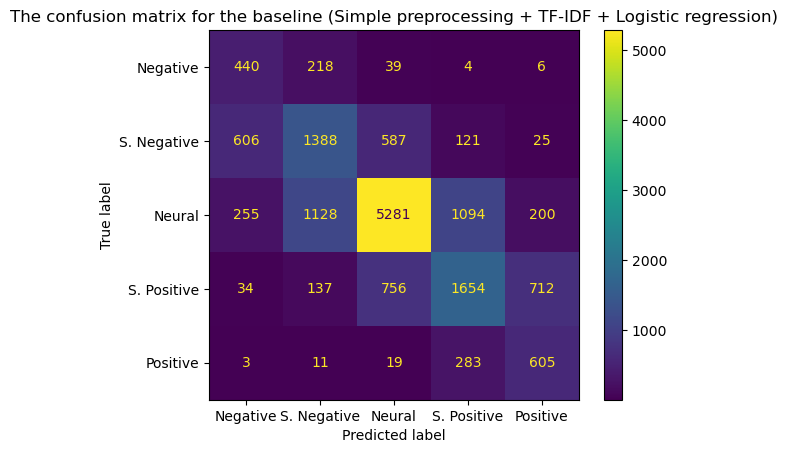

In [ ]:
cm = confusion_matrix(y_true=y_val, y_pred=y_pred)

cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

plt.figure(figsize=(10, 5))

cm.plot()

plt.title("The confusion matrix for the baseline (Simple preprocessing + TF-IDF + Logistic regression)")
plt.show()

---

##### ❌ Let's do a simple error analysis

In [ ]:
preds = lr.predict(X_val_vec)

In [ ]:
import pandas as pd

error_df = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "pred_label": preds
})

In [ ]:
error_df.head()

,text,true_label,pred_label
42999,", this movie strangely enough has the outdated swagger of a shameless ` 70s blaxploitation shuck-and-jive sitcom .",1,1
97251,match his subject,2,2
19256,have taken an small slice of history,2,4
130292,heading nowhere,2,2
110943,been thoroughly debated in the media,2,2


In [ ]:
errors = error_df[error_df["true_label"] != error_df["pred_label"]]

Get the errors sample to investigate

In [ ]:
errors.head()

,text,true_label,pred_label
19256,have taken an small slice of history,2,4
108397,", you 'd want to smash its face in",2,1
47735,of pure craft and passionate heart,4,3
54822,too-long,2,0
73465,emotionally accessible,2,4


Take randomly for inspection

In [ ]:
errors.sample(10, random_state=42)

,text,true_label,pred_label
80681,"an unusually dry-eyed , even analytical approach to material that is generally",3,1
84946,a decent draft,2,3
37518,has been sacrificed for the sake of spectacle,1,0
9962,walked away from this new version of e.t.,0,4
155102,brilliant touches,3,4
52497,works as well as it does because of the performances .,2,3
29777,'s only acting,2,0
139394,sober us up with the transparent attempts at moralizing,2,1
100576,of hollywood fluff,0,1
81281,reviewers,3,2


Beautiful confusion matrix

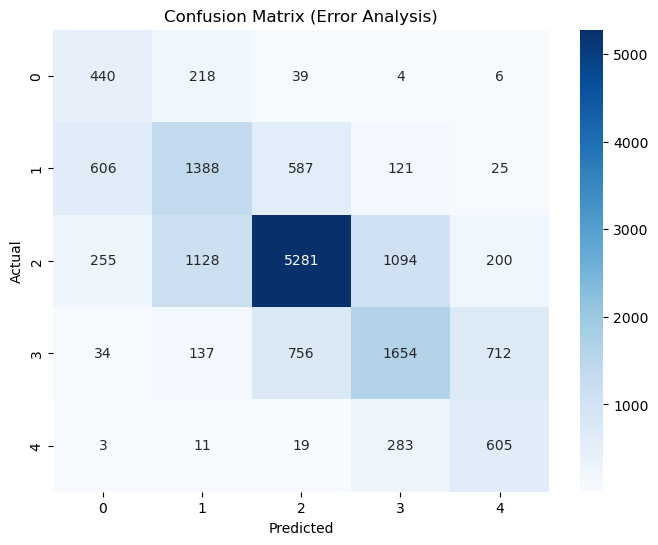

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

confusion = pd.crosstab(
    error_df["true_label"],
    error_df["pred_label"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

plt.figure(figsize=(8,6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Error Analysis)")
plt.show()

In [ ]:
errors[(errors["true_label"] == 0) & (errors["pred_label"] == 2)].head(10)

,text,true_label,pred_label
64407,a stumblebum,0,2
108524,a devastating indictment of unbridled greed and materalism .,0,2
151498,condescension from every pore .,0,2
20546,pathetically compare notes about their budding amours,0,2
67485,will be from unintentional giggles -- several of them .,0,2
146211,"rifkin no doubt fancies himself something of a hubert selby jr. , but there is n't an ounce of honest poetry in his entire script ;",0,2
56067,comedy death,0,2
58070,fulfills the minimum requirement of disney animation,0,2
22825,illness,0,2
29549,"personally , i 'd rather watch them on the animal planet .",0,2


In [ ]:
errors[(errors["true_label"] == 2) & (errors["pred_label"] == 3)].head(10)

,text,true_label,pred_label
150786,since christopher walken kinda romanced cyndi lauper in the opportunists,2,3
83875,the suspense,2,3
135698,"may not_be as cutting , as witty or as true as back in the glory days of weekend and two or three things i know about her , but who else engaged in filmmaking today is so cognizant of the cultural and moral issues involved in the process",2,3
142898,few new swings,2,3
59405,strengths,2,3
77639,biting off such a big job,2,3
71081,paint-by-number american blockbusters,2,3
126619,depicts this relationship with economical grace,2,3
45087,his homework,2,3
120768,'s true,2,3


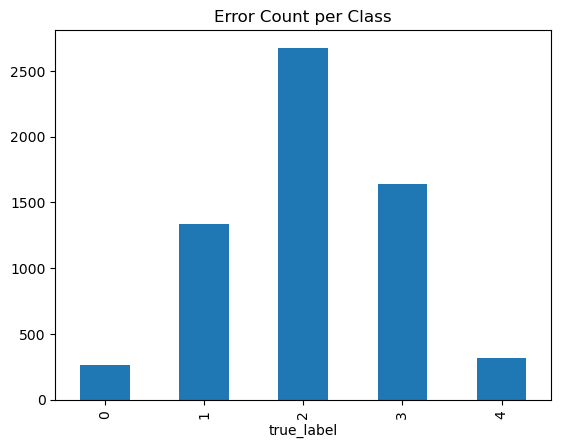

In [ ]:
error_counts = error_df[error_df["true_label"] != error_df["pred_label"]].groupby("true_label").size()

error_counts.plot(kind="bar")
plt.title("Error Count per Class")
plt.show()

In [ ]:
from collections import Counter
import re

def get_words(text):
    return re.findall(r"\w+", text.lower())

all_error_words = Counter()

for text in errors["text"]:
    all_error_words.update(get_words(text))

all_error_words.most_common(20)

[('the', 2249),
 ('a', 1664),
 ('of', 1418),
 ('and', 1371),
 ('to', 1027),
 ('s', 742),
 ('is', 635),
 ('in', 579),
 ('that', 572),
 ('it', 545),
 ('as', 405),
 ('with', 367),
 ('film', 341),
 ('for', 341),
 ('its', 310),
 ('an', 280),
 ('movie', 276),
 ('but', 270),
 ('this', 251),
 ('be', 236)]

- the model confuses adjacent sentiment classes (The model understands direction of sentiment, but not fine-grained intensity) -- understand it is negative, but not fine-grained to S. Negative or Negative
- polarity flipping in short phrases
- sentiment depends on composition, not keywords (has been sacrified for the sake of spectacle)
- neutral class is a “catch-all bucket”
- positive words !=  positive sentiment -> struggles with intensity scaling

#### ⚾ Try baseline with SVM (skipped)

In [ ]:
# wandb.init(
#     entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
#     project="sentiment-analysis-on-movie-reviews",
#     group="ML_SVM",
#     name="svm_tfidf_v1",
#     config={
#         "task": "sentiment_classification",
#         "num_classes": 5,
#         "model": "LinearSVC",
#         "vectorizer": vectorizer_config,
#         "dataset": "Rotten Tomatoes"
#     }
# )

# svm = LinearSVC()
# svm.fit(X_train_vec, y_train)

# y_pred = svm.predict(X_val_vec)

# acc = accuracy_score(y_val, y_pred)
# f1_macro = f1_score(y_val, y_pred, average="macro")
# f1_weighted = f1_score(y_val, y_pred, average="weighted")

# wandb.log({
#     "val_accuracy": acc,
#     "val_f1_macro": f1_macro,
#     "val_f1_weighted": f1_weighted
# })

# wandb.finish()

val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_accuracy,0.64603
val_f1_macro,0.48518
val_f1_weighted,0.61896


val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_accuracy,0.65776
val_f1_macro,0.54229
val_f1_weighted,0.64909


---

### 👦 Authors

- ChatGPT
- Dung Le